<a href="https://colab.research.google.com/github/cesarelizondo/analysis-connectatel/blob/main/Analysis_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      str    
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), str(1)
memory usage: 260.0 bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     4000 non-null   int64
 1   first_name  4000 non-null   str  
 2   last_name   4000 non-null   str  
 3   age         4000 non-null   int64
 4   city        3531 non-null   str  
 5   reg_date    4000 non-null   str  
 6   plan        4000 non-null   str  
 7   churn_date  466 non-null    str  
dtypes: int64(2), str(6)
memory usage: 250.1 KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  str    
 3   date      39950 non-null  str    
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), str(2)
memory usage: 1.8 MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())  # Cantidad de valores nulos
print()
print(users.isna().mean() * 100)  # Proporción de valores nulos (%)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())  # Cantidad de valores nulos
print()
print(usage.isna().mean() * 100)  # Proporción de valores nulos (%)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Diagnóstico:**
- En `users`, la columna `city` tiene **469 nulos (11.7%)**. Es un porcentaje moderado: se investigará junto con el sentinel `"?"` (otro 2.4% adicional) y se dejará como nulo, ya que no hay forma confiable de imputar la ciudad de un cliente.
- En `users`, la columna `churn_date` tiene **3,534 nulos (88.35%)**. Este nulo **no es un error**: representa a los clientes que **siguen activos** (no han hecho churn). No se debe imputar ni eliminar, se interpretará como "cliente activo".
- En `usage`, la columna `date` tiene **50 nulos (0.125%)**. Proporción mínima; se puede dejar como nulo o eliminar esas filas sin afectar el análisis.
- En `usage`, `duration` tiene **22,076 nulos (55.19%)** y `length` tiene **17,896 nulos (44.74%)**. Estos altos porcentajes **no son un error de captura**: `duration` solo aplica a registros `type == 'call'` y `length` solo aplica a `type == 'text'`. Se confirmará esta hipótesis (MAR) en la sección 3.2 y se dejarán como nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es un identificador único secuencial (de 10000 a 13999), no presenta valores fuera de rango ni duplicados aparentes.
- La columna `age` presenta un **sentinel `-999`**, visible en el valor mínimo y que distorsiona la media (33.7) y la desviación estándar (123.2). El resto de los valores se ubica en un rango razonable (18 a 79 años).

In [ ]:
# explorar columnas numéricas de usage
usage[['duration', 'length']].describe()

,duration,length
count,17924.000000,22104.000000
mean,5.202237,52.127398
std,6.842701,56.611183
min,0.000000,0.000000
25%,1.437500,37.000000
50%,3.500000,50.000000
75%,6.990000,64.000000
max,120.000000,1490.000000


- Las columnas `id` y `user_id`... `id` es el identificador único de cada registro de uso (llamada o mensaje); `user_id` enlaza cada registro con la tabla `users` y se repite varias veces (un usuario genera múltiples registros).
- Las columnas `duration` y `length` no presentan sentinels evidentes: sus mínimos son 0 y los máximos (120 minutos y 1490 caracteres) son razonables como valores extremos de uso, no como errores de captura. Se revisarán como posibles outliers más adelante.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- {col} ---")
    print(users[col].value_counts(dropna=False))
    print()

--- city ---
city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

--- plan ---
plan
Basico     2595
Premium    1405
Name: count, dtype: int64



- La columna `city` tiene 6 ciudades válidas (Bogotá, CDMX, Medellín, GDL, MTY, Cali), además de **96 registros con el sentinel `"?"`** y 469 valores nulos genuinos. El sentinel debe convertirse en nulo para no confundirlo con una categoría real.
- La columna `plan` solo contiene dos valores válidos (`Basico` y `Premium`), sin sentinels ni inconsistencias de escritura (mayúsculas/minúsculas, espacios, etc.).

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

type
text    22092
call    17908
Name: count, dtype: int64

- La columna `type` solo contiene dos valores válidos: `call` (17,908 registros) y `text` (22,092 registros), sin sentinels ni errores de escritura.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

**Diagnóstico:**
- `age` (users): sentinel `-999` en una pequeña cantidad de registros. Acción: reemplazar por la **mediana** de la columna, ya que es una medida robusta frente a outliers y sentinels.
- `city` (users): sentinel `"?"` en 96 filas (2.4%). Acción: convertir a `pd.NA` para tratarlo de forma consistente junto con los nulos genuinos de la columna.
- No se detectaron sentinels en `plan`, `type`, `duration` ni `length`.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64

En `reg_date`, la mayoría de los registros caen entre 2022 y 2024, lo cual es coherente con la operación de la empresa. Sin embargo, **40 registros tienen año 2026**, una fecha futura imposible dado que los datos están registrados hasta 2024. Estos se marcarán como nulos en el siguiente paso.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

date
2024.0    39950
NaN          50
Name: count, dtype: int64

En `date`, todos los registros válidos corresponden al año **2024** (39,950 filas), más 50 valores nulos que ya se habían detectado. No se observan años fuera de rango.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Diagnóstico:**
- En `reg_date` aparecen **40 registros con año 2026**, una fecha que aún no ha transcurrido respecto al periodo de los datos (hasta 2024). Es un error de captura. Acción: marcarlas como `pd.NA`, ya que no es seguro asumir cuál era la fecha real de registro.
- En `date` (usage) no se encontraron años imposibles; todos los registros válidos corresponden a 2024.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

city
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: count, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NA

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

reg_date
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: count, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda s: s.isna().mean() * 100)

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda s: s.isna().mean() * 100)

type
call    99.932991
text     0.000000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

**Diagnóstico:**
- `duration` está prácticamente vacía (99.93% nulos) cuando `type == 'text'` y completa (0% nulos) cuando `type == 'call'`. Esto confirma que `duration` **solo aplica a llamadas**: un mensaje de texto no tiene una "duración" en minutos.
- De forma simétrica, `length` está vacía (99.93% nulos) cuando `type == 'call'` y completa (0% nulos) cuando `type == 'text'`, ya que `length` representa la longitud del mensaje y no aplica a llamadas.
- Los nulos dependen completamente de la variable `type`, por lo que se trata de un patrón **MAR (Missing At Random)** explicado por el diseño del dataset, no de un error de captura. **Se dejarán como nulos**, ya que reemplazarlos (por ejemplo con 0) distorsionaría las métricas de duración real de llamadas y longitud real de mensajes.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    is_text=('is_text', 'sum'),
    is_call=('is_call', 'sum'),
    duration=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

# Los usuarios sin registros en usage quedan como NaN tras el merge;
# se reemplazan por 0, ya que representan 0 mensajes, 0 llamadas y 0 minutos
cols_uso = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[cols_uso] = user_profile[cols_uso].fillna(0)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

plan
Basico     64.875
Premium    35.125
Name: proportion, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

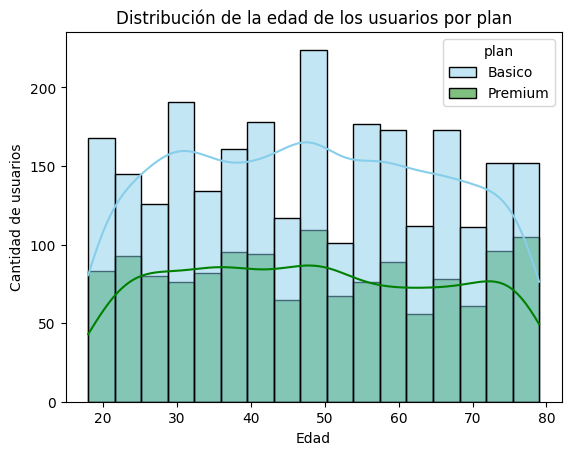

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de la edad de los usuarios por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- La distribución de `age` es prácticamente **simétrica/uniforme**, cubriendo de forma pareja el rango de 18 a 79 años.
- No existe un patrón claro entre la edad y el tipo de plan: tanto el plan Básico como el Premium tienen usuarios distribuidos de manera similar en todos los rangos de edad. La edad no parece ser un factor determinante para elegir un plan u otro.

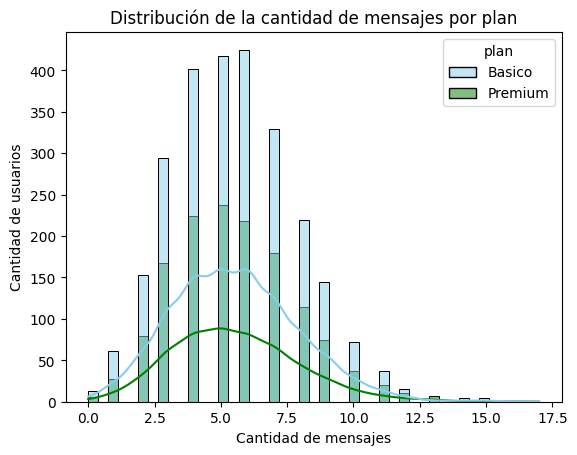

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de la cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- La distribución de `cant_mensajes` es **ligeramente sesgada a la derecha** (la mayoría de usuarios envía entre 4 y 7 mensajes, con una cola de usuarios que envían más).
- Los usuarios Básico y Premium tienen un comportamiento de envío de mensajes prácticamente idéntico; no existe un patrón diferenciador claro asociado al plan.

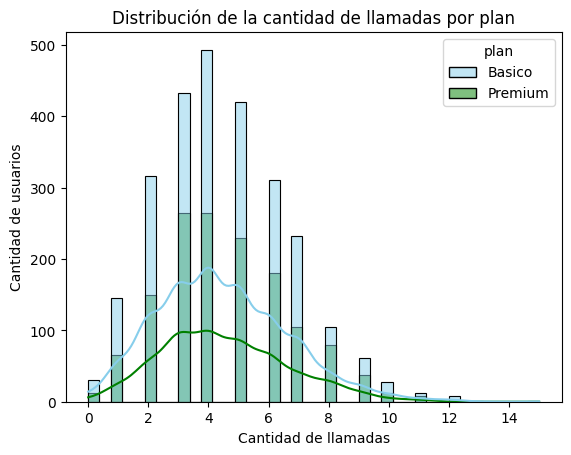

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de la cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- La distribución de `cant_llamadas` es **ligeramente sesgada a la derecha**, similar a `cant_mensajes`.
- Tampoco aquí se observa un patrón diferenciador entre planes: ambos grupos realizan en promedio entre 4 y 5 llamadas, sin que el plan Premium muestre mayor actividad.

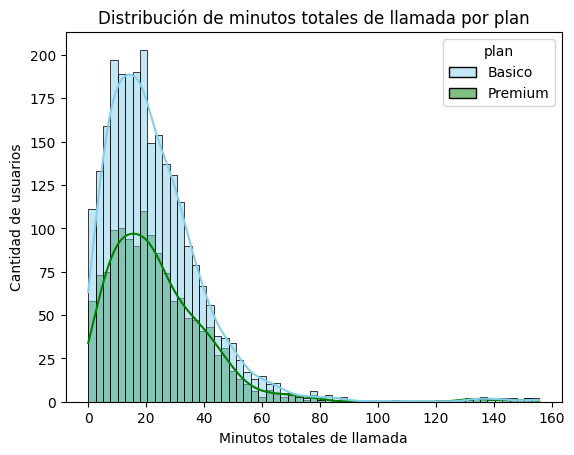

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de minutos totales de llamada por plan')
plt.xlabel('Minutos totales de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- `cant_minutos_llamada` muestra una **distribución sesgada fuertemente a la derecha**: la mayoría de los usuarios concentra entre 0 y 35 minutos, pero existe una cola larga de usuarios con consumos mucho mayores (hasta más de 150 minutos), lo que sugiere presencia de outliers.
- No hay diferencia notable entre planes Básico y Premium en minutos consumidos, reforzando que el uso real no está alineado con el tipo de plan contratado.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

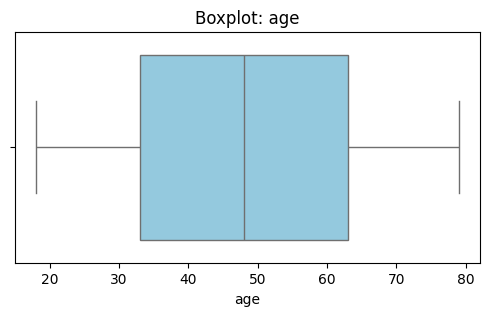

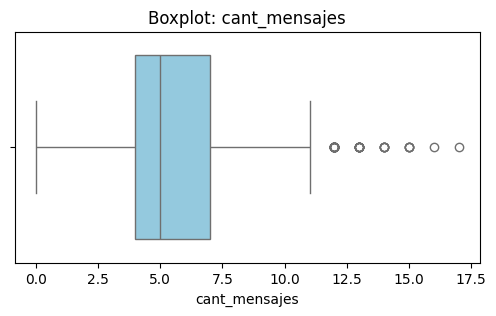

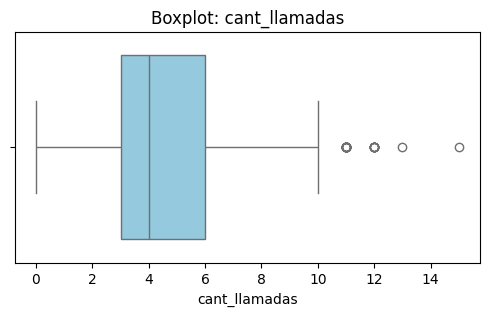

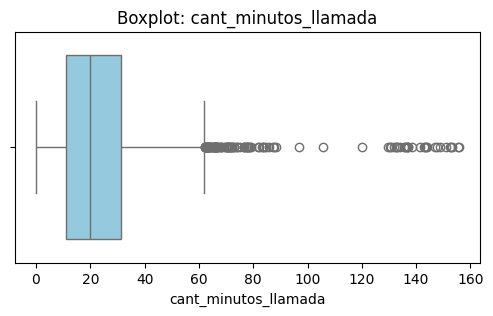

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: no presenta outliers; los valores se distribuyen de forma uniforme entre 18 y 79 años, sin puntos fuera de los bigotes del boxplot.
- cant_mensajes: presenta outliers en el extremo superior (usuarios que envían más de ~11-12 mensajes).
- cant_llamadas: presenta outliers en el extremo superior (usuarios con más de ~10-11 llamadas).
- cant_minutos_llamada: presenta outliers claros en el extremo superior, con usuarios que acumulan muchos más minutos que el resto (hasta 155 minutos frente a una mediana de ~20).

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
limites_superiores = {}

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limites_superiores[col] = q3 + 1.5 * iqr
    print(f"{col}: límite superior = {limites_superiores[col]:.2f}")

cant_mensajes: límite superior = 11.50
cant_llamadas: límite superior = 10.50
cant_minutos_llamada: límite superior = 61.87


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
print(user_profile[columnas_limites].describe())
print()
print("Límites superiores (IQR):", limites_superiores)

       cant_mensajes  cant_llamadas  cant_minutos_llamada
count    4000.000000    4000.000000           4000.000000
mean        5.523000       4.477000             23.311225
std         2.359738       2.145139             18.169564
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.107500
50%         5.000000       4.000000             19.780000
75%         7.000000       6.000000             31.412500
max        17.000000      15.000000            155.690000

Límites superiores (IQR): {'cant_mensajes': np.float64(11.5), 'cant_llamadas': np.float64(10.5), 'cant_minutos_llamada': np.float64(61.870000000000005)}


💡Insights:
- cant_mensajes: **mantener los outliers**. El máximo (17 mensajes) no es absurdo para un usuario activo y representa un comportamiento real de uso intensivo, no un error de captura.
- cant_llamadas: **mantener los outliers**. El máximo (15 llamadas) es coherente con el resto del rango y refleja usuarios con mayor actividad telefónica, no valores imposibles.
- cant_minutos_llamada: **mantener los outliers**. Aunque el límite superior IQR es de aproximadamente 62 minutos y el máximo observado es de 155.69 minutos, este valor es razonable en el contexto de telecomunicaciones (algunas llamadas o la suma de varias llamadas largas en el periodo). Estos usuarios de alto consumo son justamente los que interesa identificar para la segmentación y las estrategias comerciales, por lo que eliminarlos haría perder información valiosa para el negocio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def asignar_grupo_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(asignar_grupo_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def asignar_grupo_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(asignar_grupo_edad)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

/tmp/ipykernel_658/858921889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='Blues')


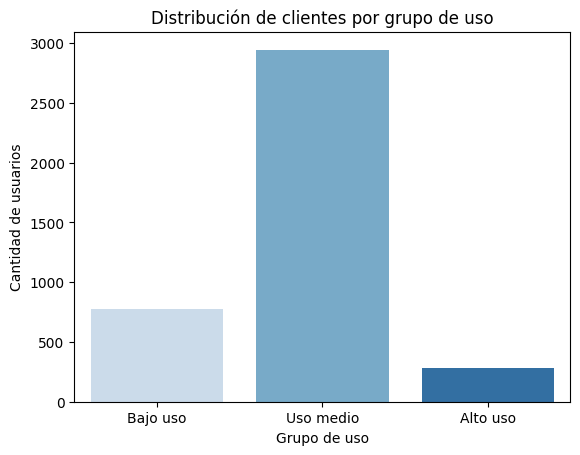

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='Blues')
plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

/tmp/ipykernel_658/1355642410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='Greens')


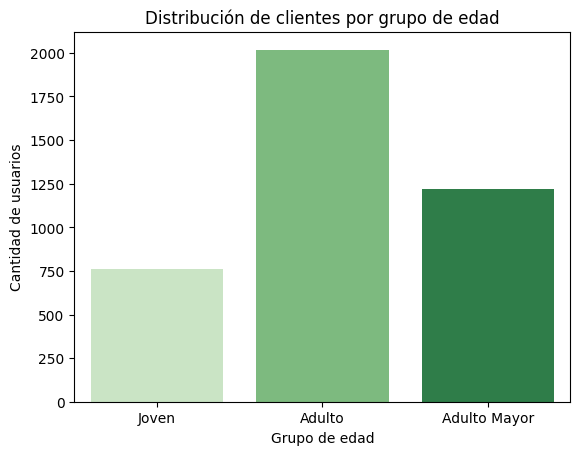

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='Greens')
plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- `age` (users) contenía un sentinel **-999** que distorsionaba la media y la desviación estándar; se corrigió imputando con la mediana.
- `city` (users) tenía un sentinel `"?"` en **96 filas (2.4%)** y **469 valores nulos genuinos (11.7%)**; ambos se trataron como nulos por falta de información confiable para imputar.
- `reg_date` (users) tenía **40 registros (1%) con año 2026**, una fecha imposible dado que los datos llegan hasta 2024; se marcaron como nulos.
- `churn_date` (users) tiene **3,534 nulos (88.35%)**, pero estos nulos **no son un problema de calidad**: representan a los clientes que todavía no han hecho churn (siguen activos).
- `duration` y `length` (usage) tienen **55.19%** y **44.74%** de nulos respectivamente, pero son nulos **MAR** explicados por el tipo de registro (`duration` solo aplica a llamadas, `length` solo a mensajes); se dejaron como nulos.
- Se detectaron **outliers en el extremo superior** de `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada` (entre 30 y 109 usuarios según la variable), que se decidió **conservar** porque representan comportamiento real de clientes de alto consumo, información clave para el negocio.


🔍 **Segmentos por Edad**
- Los clientes se dividen en **Adulto** (2,018, ~50.5%), **Adulto Mayor** (1,222, ~30.6%) y **Joven** (760, ~19%).
- La edad **no está asociada** con el tipo de plan contratado ni con un mayor o menor uso del servicio: los tres grupos consumen mensajes, llamadas y minutos de forma muy similar.
- La tasa de churn es ligeramente más alta en el grupo **Adulto** (~12.5%) frente a Adulto Mayor (~11%) y Joven (~10.5%), aunque la diferencia es moderada.


📊 **Segmentos por Nivel de Uso**
- La mayoría de los clientes se concentra en **Uso medio** (2,943, ~73.6%), seguido de **Bajo uso** (779, ~19.5%) y **Alto uso** (278, ~7%).
- Los clientes de **Alto uso** presentan la tasa de churn más alta (~14%) frente a Uso medio y Bajo uso (~11.4% ambos), lo que sugiere que los usuarios más intensivos también son los que más probablemente cancelan el servicio, posiblemente por insatisfacción con los límites o costos del plan actual.
- La proporción de clientes con plan Básico vs Premium es prácticamente la misma en los tres grupos de uso (~65% Básico / ~35% Premium), lo que confirma que el plan contratado **no refleja** el nivel real de consumo del cliente.


➡️ Esto sugiere que el plan contratado (Básico/Premium) **no es un buen predictor del comportamiento real de uso** de los clientes: hay usuarios de alto consumo en el plan Básico (que probablemente paguen cargos extra) y usuarios de bajo consumo en el plan Premium (que probablemente estén pagando de más por capacidad que no usan). Esta desalineación entre plan y uso real, sumada a la mayor tasa de churn en el segmento de Alto uso, apunta a una oportunidad de **rediseño de planes** y de **estrategias de retención dirigidas** a los clientes más intensivos.


💡 **Recomendaciones**
- Crear un **plan intermedio o "Plus"** dirigido específicamente al segmento de Alto uso, con más minutos/mensajes incluidos a un costo por unidad más competitivo, para reducir la fricción de cargos extra que podría estar impulsando el churn en ese grupo.
- Implementar alertas o recomendaciones automáticas de cambio de plan cuando un cliente del plan Básico se acerque sistemáticamente a sus límites incluidos, evitando sorpresas en la factura y mejorando la experiencia.
- Diseñar una **campaña de retención proactiva** enfocada en clientes de Alto uso (la tasa de churn más alta), ofreciendo beneficios o descuentos antes de que decidan cancelar.
- Revisar la estrategia de precios del plan Premium: dado que el uso real no difiere significativamente del plan Básico, conviene evaluar si el valor percibido (GB, minutos, mensajes incluidos) está bien comunicado o si se necesita un beneficio adicional (ej. roaming, soporte prioritario) que justifique la diferencia de precio.
- Profundizar en un análisis de churn más detallado (por ejemplo, con variables de antigüedad o ciudad) para entender mejor las causas de cancelación y diseñar acciones de retención más específicas.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`